# xView: Raster Data Engineering

> This notebook demonstrates using a distributed raster API to load TIFs into Lakehouse tables + clip objects.

<img src="https://geospatialmedia.s3.amazonaws.com/wp-content/uploads/2018/02/example6.jpg" width="50%"/>
</p>
<img src="https://geospatialmedia.s3.amazonaws.com/wp-content/uploads/2018/02/Screen-Shot-2018-02-23-at-6.22.39-PM.png" width="50%"/>

---
_Last Modified:_ April 21, 2026

## [1] Setup

In [0]:
%pip install --quiet --disable-pip-version-check --ignore-installed --no-deps geobrix
%pip install --quiet "geobrix[light] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.4.0-py3-none-any.whl"

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
# Force every tableExists() guard below to rebuild (don't skip any logic).
FORCE_REBUILD = False  # re-run: skip tables already built; set True to force a full rebuild

In [0]:
# replace with your catalog and schema
catalog_name = "geospatial_docs"
schema_name = "xview"

sql(f"""USE CATALOG {catalog_name}""")
sql(f"""CREATE DATABASE IF NOT EXISTS {schema_name}""")
sql(f"""USE DATABASE {schema_name}""")

print(f"... catalog: '{catalog_name}' (USE)")
print(f"... schema: '{schema_name}' (CREATE / USE)")

... catalog: 'geospatial_docs' (USE)
... schema: 'xview' (CREATE / USE)


In [0]:
VOL_BASE_DIR = f"/Volumes/{catalog_name}/{schema_name}/data"
VOL_TIFF_DIR = f"{VOL_BASE_DIR}/train_images"
VOL_LABELS_GEOJSON = f"{VOL_BASE_DIR}/train_labels/xView_train.geojson"

In [0]:
from pyspark.sql import functions as F
from pyspark.databricks.sql import functions as DBF

In [0]:
# -- option-1: geobrix (lightweight tier for sql expressions, just pip install)
from databricks.labs.gbx.pyrx import functions as rx

# -- option-2: geobrix (heavyweight tier for sql expressions, requires more setup)
#from databricks.labs.gbx.rasterx import functions as rx # <- rx.rst_* python bindings

rx.register(spark) # <- you can invoke functions now via spark sql

In [0]:
# register light readers and writers; heavyweight would be automatically installed
from databricks.labs.gbx.ds.register import register
register(spark)

In [0]:
# https://spark.apache.org/docs/latest/configuration.html
# spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "false")
# spark.conf.set("spark.sql.shuffle.partitions", 512)

from io import BytesIO
from matplotlib import pyplot
from rasterio.io import MemoryFile
from rasterio.plot import show
import rasterio

def plot_raster(raster, fig_w=8, fig_h=8):
  fig, ax = pyplot.subplots(1, figsize=(fig_w, fig_h))

  with MemoryFile(BytesIO(raster)) as memfile:
    with memfile.open() as src:
      show(src, ax=ax)
      pyplot.show()


def plot_file(file_path, fig_w=8, fig_h=8):
  fig, ax = pyplot.subplots(1,  figsize=(fig_w, fig_h))

  with rasterio.open(file_path.replace('dbfs:','')) as src:
    show(src, ax=ax)
    pyplot.show()

### Download xView Data

> You have to go to https://challenge.xviewdataset.org/welcome and setup an account, then you can proceed with your session-based links from https://challenge.xviewdataset.org/download-links; we are using the TGZ links.

In [0]:
import os
import shutil
from pathlib import Path

def clean_tmp_dir(folder_name):
    """
    For manual cleanup
    """
    local_scratch = Path(f"/tmp/{folder_name}")
    if local_scratch.exists(): shutil.rmtree(local_scratch)


def clean_local_scratch(final_folder_name):
    clean_tmp_dir(f"extract_{final_folder_name}")

In [0]:
def download_extract(url, target_base_dir, folder_name):
    """
    Extracts to local /tmp via shell and copies to Volume via shell.
    Bypasses dbutils permission restrictions.
    """
    # 1. Setup Paths
    vol_final_dir = Path(f"{target_base_dir}/{folder_name}").absolute()
    local_scratch = Path(f"/tmp/extract_{folder_name}")
    
    # 2. Skip if already exists on Volume
    if vol_final_dir.exists() and any(vol_final_dir.iterdir()):
        print(f"✅ {folder_name} already exists on Volume. Skipping.")
        return

    # 3. Prepare Local SSD
    clean_local_scratch(folder_name)
    local_scratch.mkdir(parents=True, exist_ok=True)
    vol_final_dir.mkdir(parents=True, exist_ok=True)

    print(f"🚀 Streaming from URL to local SSD (/tmp)...")
    
    # We extract into /tmp. We don't use --strip-components here to be safe.
    # We let tar do whatever it wants inside /tmp.
    extract_cmd = (
        f"curl -L '{url}' | "
        f"tar -xz -C '{local_scratch}' "
        f"--exclude='._*' --exclude='__MACOSX' --exclude='.DS_Store'"
    )
    
    if os.system(extract_cmd) != 0:
        print("❌ Extraction failed.")
        return

    # 4. Find the actual data (Solving the Nesting Problem)
    # We look for where the first .tif file is to identify the real data folder
    print("🔍 Locating images and flattening structure...")
    # This shell command finds the directory containing the first .tif file
    find_cmd = f"find {local_scratch} -name '*.tif' -print -quit | xargs dirname"
    actual_data_source = os.popen(find_cmd).read().strip()

    if not actual_data_source:
        print("❌ Could not find any images in the extracted archive.")
        return

    print(f"📂 Found data in: {actual_data_source}")

    # 5. Fast Shell Copy from /tmp to Volume
    # 'cp -rp' copies contents recursively and preserves attributes.
    # We use '/.' at the end of the source to copy contents, NOT the folder itself.
    print(f"📤 Uploading to Volume: {vol_final_dir}...")
    
    # This is the fastest move possible on Databricks because it uses the 
    # OS-level optimized copy buffer.
    copy_cmd = f"cp -rp '{actual_data_source}/.' '{vol_final_dir}/'"
    
    if os.system(copy_cmd) == 0:
        print(f"✨ Successfully moved data to {vol_final_dir}")
    else:
        print("❌ Failed to copy data to Volume. Check Volume space.")

    # 6. Cleanup Local SSD
    print("🧹 Cleaning up local scratch...")
    shutil.rmtree(local_scratch)

In [0]:
labels_url = "<from xView>"
download_extract(labels_url, VOL_BASE_DIR, "train_labels")

✅ train_labels already exists on Volume. Skipping.


In [0]:
train_url = "<from xView>"
download_extract(train_url, VOL_BASE_DIR, "train_images")

✅ train_images already exists on Volume. Skipping.


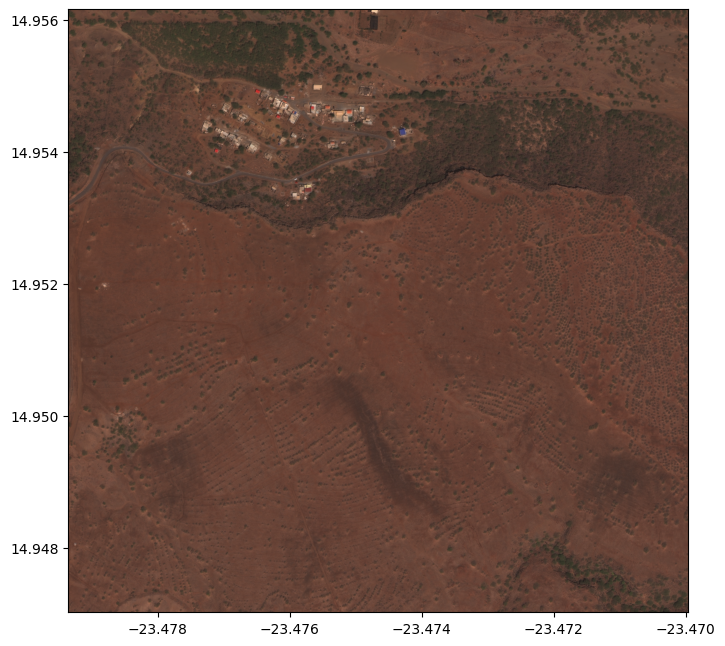

In [0]:
plot_file(f"{VOL_BASE_DIR}/train_images/10.tif")

## [2] Load Rasters

__Load from Volume.__

> For rendering, see https://docs.databricks.com/aws/en/query/formats/binary

_Uncomment the following within databricks for actual results._ 

In [0]:
displayHTML("""<img src="data:image/jpeg;base64, ..." width="100%" />""")

In [0]:
tif_df = (
  spark
    .read
    .format("gtiff_gbx")
    .option("filterRegex", r".*\.tif$")
    .load(VOL_TIFF_DIR)
)
tif_df.limit(1).show(vertical=True)

__Extract `size`, `bbox`, and `srid`.__

In [0]:
if FORCE_REBUILD or not spark.catalog.tableExists("xview_raster"):
  (
    tif_df
      .withColumnRenamed("source", "path") # <- dbfs:-qualified full path (per-image id)
      .withColumn("image_file", F.element_at(F.split(F.col("path"), "/"), -1)) # <- basename join key
      .withColumn("bbox", rx.rst_boundingbox("tile"))
      .withColumn("srid", rx.rst_srid("tile"))
      .write
        .option("overwriteSchema", "true")
        .mode("overwrite")
        .saveAsTable("xview_raster")
  )

raster_df = spark.table("xview_raster")
raster_df.limit(1).show(vertical=True)

-RECORD 0--------------------------------
 path             | dbfs:/Volumes/geo... 
 modificationTime | 2026-04-20 19:13:49  
 length           | 32190176             
 tile             | {0, [49 49 2A 00 ... 
 bbox             | [00 00 00 00 03 0... 
 srid             | 4326                 




__We can invoke `rst_summary` to get metadata about rasters. For xView we find that these are 3 band rasters (RGB) and confirm they are WGS84 (4326).__

In [0]:
(
  raster_df
    .select("path", rx.rst_summary("tile"))
    .limit(1)
    .display()
)

path gbx_rst_summary(tile, expr_config_expr()) dbfs:/Volumes/geospatial_docs/xview/data/train_images/10.tif {
 "description":"/vsimem/temp_raster_dab08db0_9acc_4b0a_99c3_62e9dd236547.tif",
 "driverShortName":"GTiff",
 "driverLongName":"GeoTIFF",
 "files":[
 "/vsimem/temp_raster_dab08db0_9acc_4b0a_99c3_62e9dd236547.tif"
 ],
 "size":[
 3320,
 3228
 ],
 "coordinateSystem":{
 "wkt":"GEOGCRS[\"WGS 84\",\n ENSEMBLE[\"World Geodetic System 1984 ensemble\",\n MEMBER[\"World Geodetic System 1984 (Transit)\"],\n MEMBER[\"World Geodetic System 1984 (G730)\"],\n MEMBER[\"World Geodetic System 1984 (G873)\"],\n MEMBER[\"World Geodetic System 1984 (G1150)\"],\n MEMBER[\"World Geodetic System 1984 (G1674)\"],\n MEMBER[\"World Geodetic System 1984 (G1762)\"],\n MEMBER[\"World Geodetic System 1984 (G2139)\"],\n MEMBER[\"World Geodetic System 1984 (G2296)\"],\n ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n LENGTHUNIT[\"metre\",1]],\n ENSEMBLEACCURACY[2.0]],\n PRIMEM[\"Greenwich\",0,\n ANGLEUNIT[\"degree\",0.0174532925199433]],\n CS[ellipsoidal,2],\n AXIS[\"geodetic latitude (Lat)\",north,\n ORDER[1],\n ANGLEUNIT[\"degree\",0.0174532925199433]],\n AXIS[\"geodetic longitude (Lon)\",east,\n ORDER[2],\n ANGLEUNIT[\"degree\",0.0174532925199433]],\n USAGE[\n SCOPE[\"Horizontal component of 3D system.\"],\n AREA[\"World.\"],\n BBOX[-90,-180,90,180]],\n ID[\"EPSG\",4326]]",
 "dataAxisToSRSAxisMapping":[
 2,
 1
 ]
 },
 "geoTransform":[
 -23.479355140231899,
 0.000002829693145,
 0.0,
 14.9561643612843085,
 0.0,
 -0.000002829693145
 ],
 "metadata":{
 "":{
 "AREA_OR_POINT":"Area"
 },
 "IMAGE_STRUCTURE":{
 "INTERLEAVE":"BAND"
 }
 },
 "cornerCoordinates":{
 "upperLeft":[
 -23.4793551,
 14.9561644
 ],
 "lowerLeft":[
 -23.4793551,
 14.9470301
 ],
 "lowerRight":[
 -23.4699606,
 14.9470301
 ],
 "upperRight":[
 -23.4699606,
 14.9561644
 ],
 "center":[
 -23.4746578,
 14.9515972
 ]
 },
 "wgs84Extent":{
 "type":"Polygon",
 "coordinates":[
 [
 [
 -23.4793551,
 14.9561644
 ],
 [
 -23.4793551,
 14.9470301
 ],
 [
 -23.4699606,
 14.9470301
 ],
 [
 -23.4699606,
 14.9561644
 ],
 [
 -23.4793551,
 14.9561644
 ]
 ]
 ]
 },
 "bands":[
 {
 "band":1,
 "block":[
 3320,
 2
 ],
 "type":"Byte",
 "colorInterpretation":"Red",
 "noDataValue":0,
 "metadata":{}
 },
 {
 "band":2,
 "block":[
 3320,
 2
 ],
 "type":"Byte",
 "colorInterpretation":"Green",
 "noDataValue":0,
 "metadata":{}
 },
 {
 "band":3,
 "block":[
 3320,
 2
 ],
 "type":"Byte",
 "colorInterpretation":"Blue",
 "noDataValue":0,
 "metadata":{}
 }
 ],
 "stac":{
 "proj:shape":[
 3228,
 3320
 ],
 "proj:wkt2":"GEOGCRS[\"WGS 84\",\n ENSEMBLE[\"World Geodetic System 1984 ensemble\",\n MEMBER[\"World Geodetic System 1984 (Transit)\"],\n MEMBER[\"World Geodetic System 1984 (G730)\"],\n MEMBER[\"World Geodetic System 1984 (G873)\"],\n MEMBER[\"World Geodetic System 1984 (G1150)\"],\n MEMBER[\"World Geodetic System 1984 (G1674)\"],\n MEMBER[\"World Geodetic System 1984 (G1762)\"],\n MEMBER[\"World Geodetic System 1984 (G2139)\"],\n MEMBER[\"World Geodetic System 1984 (G2296)\"],\n ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n LENGTHUNIT[\"metre\",1]],\n ENSEMBLEACCURACY[2.0]],\n PRIMEM[\"Greenwich\",0,\n ANGLEUNIT[\"degree\",0.0174532925199433]],\n CS[ellipsoidal,2],\n AXIS[\"geodetic latitude (Lat)\",north,\n ORDER[1],\n ANGLEUNIT[\"degree\",0.0174532925199433]],\n AXIS[\"geodetic longitude (Lon)\",east,\n ORDER[2],\n ANGLEUNIT[\"degree\",0.0174532925199433]],\n USAGE[\n SCOPE[\"Horizontal component of 3D system.\"],\n AREA[\"World.\"],\n BBOX[-90,-180,90,180]],\n ID[\"EPSG\",4326]]",
 "proj:epsg":4326,
 "proj:projjson":{
 "$schema":"https://proj.org/schemas/v0.7/projjson.schema.json",
 "type":"GeographicCRS",
 "name":"WGS 84",
 "datum_ensemble":{
 "name":"World Geodetic System 1984 ensemble",
 "members":[
 {
 "name":"World Geodetic System 1984 (Transit)",
 "id":{
 "authority":"EPSG",
 "code":1166
 }
 },
 {
 "name":"World Geodetic System 1984 (G730)",
 "id":{
 "authority":"EPSG",
 "code":1152
 }
 },
 {
 "name":"World Geodetic System 1984

## [3] Raster: Detected Objects

> Here is an example GeoJSON for an object.

```
{
  "type": "Feature",
  "properties": {
    "bounds_imcoords": "91,351,102,365",
    "edited_by": "wwgabrielfernandez",
    "cat_id": "104001002B423500",
    "type_id": 73,
    "ingest_time": "2017/08/15 14:08:07.857+00",
    "index_right": 118,
    "image_id": "118.tif",
    "point_geom": "0101000020E61000004FB3E9759CBD58C086992999554D3340",
    "feature_id": 709520,
    "grid_file": "Grid5.shp"
  },
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          -98.96265661642994,
          19.302109705032297
        ],
        [
          -98.96265661642994,
          19.302065047500992
        ],
        [
          -98.96269257756853,
          19.302065047500992
        ],
        [
          -98.96269257756853,
          19.302109705032297
        ],
        [
          -98.96265661642994,
          19.302109705032297
        ]
      ]
    ]
  }
}
```

__Class Labels__

> From https://raw.githubusercontent.com/DIUx-xView/xView1_baseline/refs/heads/master/xview_class_labels.txt

In [0]:
xv_type_dict = {
11:'Fixed-wing Aircraft',
12:'Small Aircraft',
13:'Passenger/Cargo Plane',
15:'Helicopter',
17:'Passenger Vehicle',
18:'Small Car',
19:'Bus',
20:'Pickup Truck',
21:'Utility Truck',
23:'Truck',
24:'Cargo Truck',
25:'Truck Tractor w/ Box Trailer',
26:'Truck Tractor',
27:'Trailer',
28:'Truck Tractor w/ Flatbed Trailer',
29:'Truck Tractor w/ Liquid Tank',
32:'Crane Truck',
33:'Railway Vehicle',
34:'Passenger Car',
35:'Cargo/Container Car',
36:'Flat Car',
37:'Tank car',
38:'Locomotive',
40:'Maritime Vessel',
41:'Motorboat',
42:'Sailboat',
44:'Tugboat',
45:'Barge',
47:'Fishing Vessel',
49:'Ferry',
50:'Yacht',
51:'Container Ship',
52:'Oil Tanker',
53:'Engineering Vehicle',
54:'Tower crane',
55:'Container Crane',
56:'Reach Stacker',
57:'Straddle Carrier',
59:'Mobile Crane',
60:'Dump Truck',
61:'Haul Truck',
62:'Scraper/Tractor',
63:'Front loader/Bulldozer',
64:'Excavator',
65:'Cement Mixer',
66:'Ground Grader',
71:'Hut/Tent',
72:'Shed',
73:'Building',
74:'Aircraft Hangar',
76:'Damaged Building',
77:'Facility',
79:'Construction Site',
83:'Vehicle Lot',
84:'Helipad',
86:'Storage Tank',
89:'Shipping container lot',
91:'Shipping Container',
93:'Pylon',
94:'Tower',
}

type_data = []
for k, v in xv_type_dict.items():
  type_data.append((k, v))

type_df = spark.createDataFrame(type_data, ["type_id", "type_name"])
# type_df.display()

In [0]:
if FORCE_REBUILD or not spark.catalog.tableExists("xview_object"):
  (
    spark
      .read
      .option("multiline", "true")
      .format("json")
    .load(VOL_LABELS_GEOJSON)
    .select(F.explode("features"))
    .select(
      DBF.st_asewkt(DBF.st_geomfromgeojson(F.to_json("col.geometry"))).alias("wkt_clip"),
      "col.properties.*"
    )
    .join(
      type_df,
      ['type_id']
    )
    .select(
      F.concat(F.lit("dbfs:"), F.lit(VOL_TIFF_DIR), F.lit('/'), "image_id").alias("path"),
      F.element_at(F.split("image_id", "/"), -1).alias("image_file"), # <- basename join key (image_id is a bare filename, e.g. "118.tif")
      "type_name",
      F.expr("* except(type_name)")
    )
    .write
        .option("overwriteSchema", "true")
        .mode("overwrite")
        .saveAsTable("xview_object")
  )

xvo_df = spark.table("xview_object")
print(f"count? {xvo_df.count():,}")
xvo_df.limit(1).show(vertical=True)

count? 601,858
-RECORD 0-------------------------------
 path            | dbfs:/Volumes/geo... 
 type_name       | Building             
 type_id         | 73                   
 wkt_clip        | SRID=4326;POLYGON... 
 bounds_imcoords | 2712,1145,2746,1177  
 cat_id          | 1040010028371A00     
 edited_by       | wwoscarbecerril      
 feature_id      | 374410               
 grid_file       | Grid2.shp            
 image_id        | 2355.tif             
 index_right     | 2356                 
 ingest_time     | 2017/07/24 12:49:... 
 point_geom      | 0101000020E610000... 



In [0]:
# xvo_df.limit(1).display()

## [4] Raster: Clip to Vector

We can apply `rst_clip`, from [docs](https://databrickslabs.github.io/geobrix/docs/api/rasterx-functions#rst_clip):

> Clips the raster to the geometry. 

__Notes:__

1. The clip argument must be [E]WKT (string) or [E]WKB (binary)
    * If using WKT or WKB, clip geom assumed to already be projected to SRID matching the underlying raster.
    * If using EWKT or EWKB, clip geom can be projected to match as needed during execution.
    * Do not pass `st_geomfromtext()` or other DBR native geometry / geography types to this function.
1. The geometry is expected to be a polygon or a multipolygon.

In [0]:
# Filtering to Yachts just to make the execution faster for demo.
# Join key: we join labels -> rasters on `image_file` (the bare basename, e.g. "118.tif").
# The xView label `image_id` is a bare filename, while the gtiff_gbx reader's `source`
# (renamed to `path`) is a dbfs:-qualified full path. Normalizing both to the basename
# makes the join robust to any path/scheme drift, so the clip count is non-zero.
if FORCE_REBUILD or not spark.catalog.tableExists("xview_object_clip"):
  (
    xvo_df
      .filter("type_name = 'Yacht'")
      .join(
        raster_df.drop("path"), # <- keep the label-side `path`; raster `path` is redundant
        ["image_file"]
      )
      .select(
        "tile", "path", "type_name", "type_id", "index_right", "feature_id", "wkt_clip"
      )
      .withColumn("tile_clip", rx.rst_clip("tile", "wkt_clip", True))
      .selectExpr(
        "tile_clip", "type_name", "path as image_path",
        "type_id", "index_right", "feature_id", "wkt_clip"
      )
      .write
        .option("overwriteSchema", "true")
        .mode("overwrite")
      .saveAsTable("xview_object_clip")
  )

xvc_df = spark.table("xview_object_clip")
print(f"...clip count? {xvc_df.count():,}")
xvc_df.limit(1).show(vertical=True)

...clip count? 450
-RECORD 0---------------------------
 tile_clip   | {0, [49 49 2A 00 ... 
 type_name   | Yacht                
 image_path  | dbfs:/Volumes/geo... 
 type_id     | 50                   
 index_right | 1459                 
 feature_id  | 3843                 
 wkt_clip    | SRID=4326;POLYGON... 



In [0]:
clip_row = (
  xvc_df
    .filter("type_name = 'Yacht'") # <- type_id=50
).first()

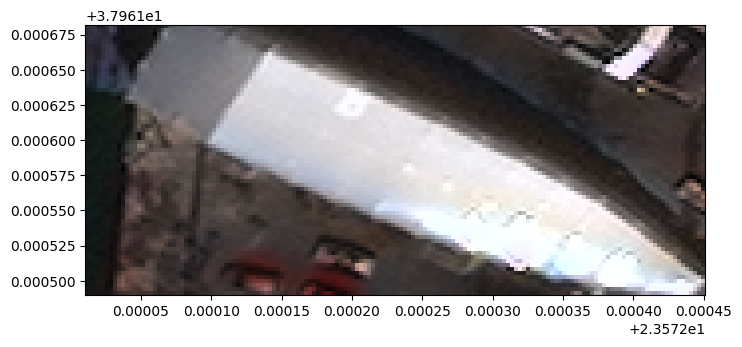

In [0]:
clip_raster = clip_row['tile_clip']['raster']
plot_raster(clip_raster)

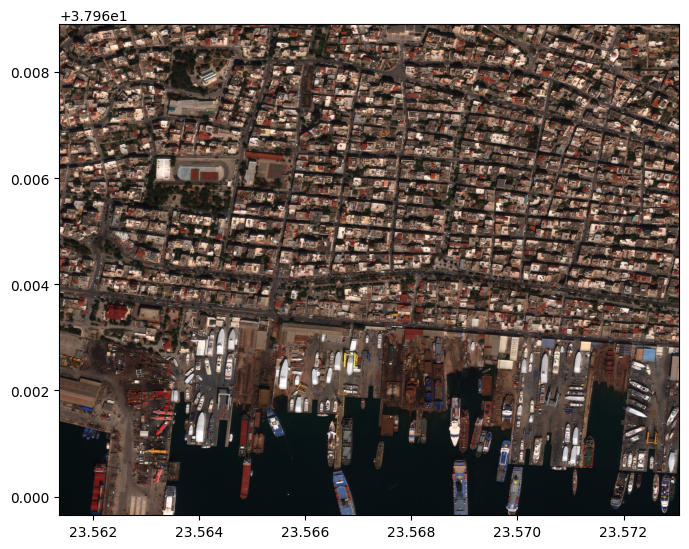

In [0]:
clip_path = clip_row['image_path']
plot_file(clip_path)

## [5] Write the clipped rasters to Volumes

In [0]:
CLIP_DIR = VOL_BASE_DIR + "/clip"
dbutils.fs.mkdirs(f"dbfs:" + CLIP_DIR)

True

In [ ]:
# Write the clipped rasters out with the lightweight gtiff_gbx writer.
# Deterministic filenames via nameCol: the writer enforces the exact
# (source, tile) schema, so put the desired name in `source` and point
# nameCol at it -> the writer emits <source>.tif (ext defaults to "tif").
(
  xvc_df
    .withColumn(
      "source",
      F.concat_ws("_", "index_right", "type_id", "feature_id")
    )
    .selectExpr("source", "tile_clip as tile") # <- exact (source, tile) schema
    .write
      .format("gtiff_gbx")
      .option("nameCol", "source")
      .mode("overwrite")
      .save(CLIP_DIR)
)


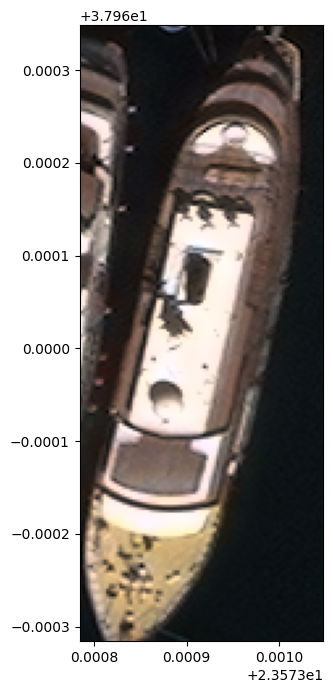

In [0]:
plot_file(f"{CLIP_DIR}/2564_50_379834.tif")

_Uncomment the following within databricks for actual results._

In [0]:
displayHTML("""<img src="data:image/jpeg;base64, ..." width="100%" />""")

In [0]:
clip_df = (
  spark
    .read
    .format("gtiff_gbx")
    .option("filterRegex", r".*\.tif$")
    .load(CLIP_DIR)
)
clip_df.limit(1).show(vertical=True)

## Summary

> We demonstrated using a distributed raster API to load TIFs into tables and clip various identified objects. Here are the tables we generated. 

In [0]:
%sql show tables

database,tableName,isTemporary
xview,xview_object,false
xview,xview_object_clip,false
xview,xview_raster,false
